#### Part 1: Basis approach using decision trees

In [15]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier, HistGradientBoostingClassifier
)
from sklearn.model_selection import (train_test_split)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from tensorflow.keras.datasets import fashion_mnist

In [16]:
# Load the data

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [17]:
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

In [18]:
# Preprocess the data: decision trees expect 2D input, so we need to flatten the images
x_train_flat = x_train.reshape(x_train.shape[0], -1) 
x_test_flat = x_test.reshape(x_test.shape[0], -1)

X_tr, X_val, y_tr, y_val = train_test_split(
    x_train_flat, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [19]:
# Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(x_train_flat, y_train)
 
y_pred = clf.predict(x_test_flat)
tree_train_acc = clf.score(x_train_flat, y_train)
tree_test_acc = accuracy_score(y_test, y_pred)
 
print("\n=== Baseline Decision Tree (no depth limit) ===")
print(f"Train accuracy: {tree_train_acc:.4f}")
print(f"Test accuracy:  {tree_test_acc:.4f}")
print(f"Tree depth reached: {clf.get_depth()}")
print(f"Number of leaves: {clf.get_n_leaves()}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))


=== Baseline Decision Tree (no depth limit) ===
Train accuracy: 1.0000
Test accuracy:  0.7890
Tree depth reached: 49
Number of leaves: 4910

Classification report:
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.73      0.75      1000
     Trouser       0.96      0.95      0.95      1000
    Pullover       0.63      0.65      0.64      1000
       Dress       0.82      0.78      0.80      1000
        Coat       0.64      0.63      0.64      1000
      Sandal       0.90      0.89      0.89      1000
       Shirt       0.52      0.55      0.54      1000
     Sneaker       0.87      0.88      0.88      1000
         Bag       0.91      0.91      0.91      1000
  Ankle boot       0.90      0.91      0.91      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



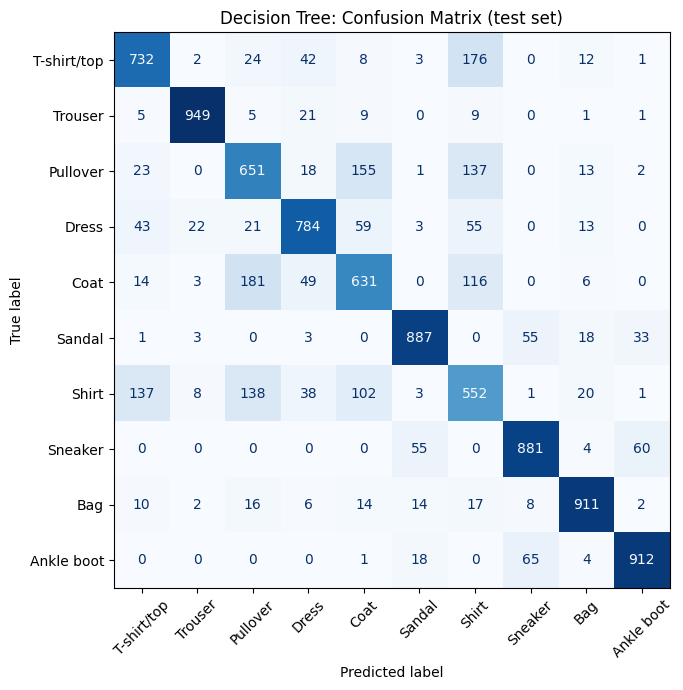

In [20]:
# Confusion Matrix

cm_tree = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
plt.title("Decision Tree: Confusion Matrix (test set)")
plt.tight_layout()
plt.show()

In [ ]:
# Depth tuning

print(f"\n{'max_depth':<10}{'train_acc':>11}{'val_acc':>11}")
depths = [5, 10, 15, 20, 25, None]
train_accs, val_accs = [], []
best_depth, best_val = None, -1

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr, y_train)
    tr_acc = dt.score(X_tr, y_train)
    va_acc = dt.score(X_val, y_val)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)
    print(f"{str(d):<10}{tr_acc:>11.4f}{va_acc:>11.4f}")
    if va_acc > best_val:
        best_val, best_depth = va_acc, d

print(f"\nBest depth on validation set: {best_depth} (val_acc={best_val:.4f})")


max_depth   train_acc    val_acc
5              0.7105     0.7030
10             0.8509     0.8130
15             0.9466     0.8107
20             0.9864     0.8034
25             0.9949     0.8012
None           1.0000     0.7973

Best depth on validation set: 10 (val_acc=0.8130)


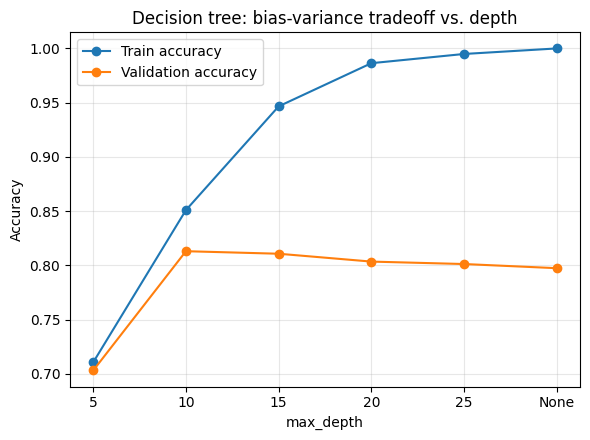

In [ ]:
# Plot the bias-variance tradeoff

x_labels = [str(d) for d in depths]
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(range(len(depths)), train_accs, marker="o", label="Train accuracy")
ax.plot(range(len(depths)), val_accs, marker="o", label="Validation accuracy")
ax.set_xticks(range(len(depths)))
ax.set_xticklabels(x_labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Decision tree: bias-variance tradeoff vs. depth")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Tuned tree (depth=10) test_acc=0.8009 (vs 0.7890 for unrestricted depth)


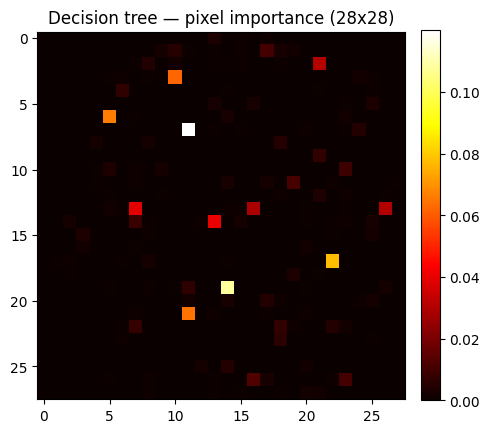

In [ ]:
# Refit the chosen depth on the full training set, evaluate once on test set
final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_tree.fit(x_train_flat, y_train)
final_tree_test_acc = accuracy_score(y_test, final_tree.predict(x_test_flat))
print(f"\nTuned tree (depth={best_depth}) test_acc={final_tree_test_acc:.4f} "
      f"(vs {tree_test_acc:.4f} for unrestricted depth)")

# Pixel importance -- useful figure for discussing WHY flattened pixels
# are a limited representation
importance_grid = final_tree.feature_importances_.reshape(28, 28)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(importance_grid, cmap="hot")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Decision tree — pixel importance (28x28)")
plt.tight_layout()
plt.show()

1b - Ensemble comparison

In [23]:
# Random Forest Ensemble
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",   # random feature subset per split -> decorrelates trees
    n_jobs=-1,
    oob_score=True,        # free validation estimate from out-of-bag samples
    random_state=42,
)
t0 = time.time()
rf.fit(x_train_flat, y_train)
rf_fit_time = time.time() - t0

y_pred_rf = rf.predict(x_test_flat)
rf_train_acc = rf.score(x_train_flat, y_train)
rf_test_acc = accuracy_score(y_test, y_pred_rf)
 
print("=== Random Forest ===")
print(f"Fit time: {rf_fit_time:.1f}s")
print(f"Train accuracy: {rf_train_acc:.4f}")
print(f"Test accuracy:  {rf_test_acc:.4f}")
print(f"OOB score: {rf.oob_score_:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))


=== Random Forest ===
Fit time: 13.0s
Train accuracy: 1.0000
Test accuracy:  0.8760
OOB score: 0.8806

Classification report:
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.86      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.77      0.81      0.79      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.77      0.82      0.79      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.71      0.58      0.64      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.95      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.87      0.88      0.87     10000
weighted avg       0.87      0.88      0.87     10000



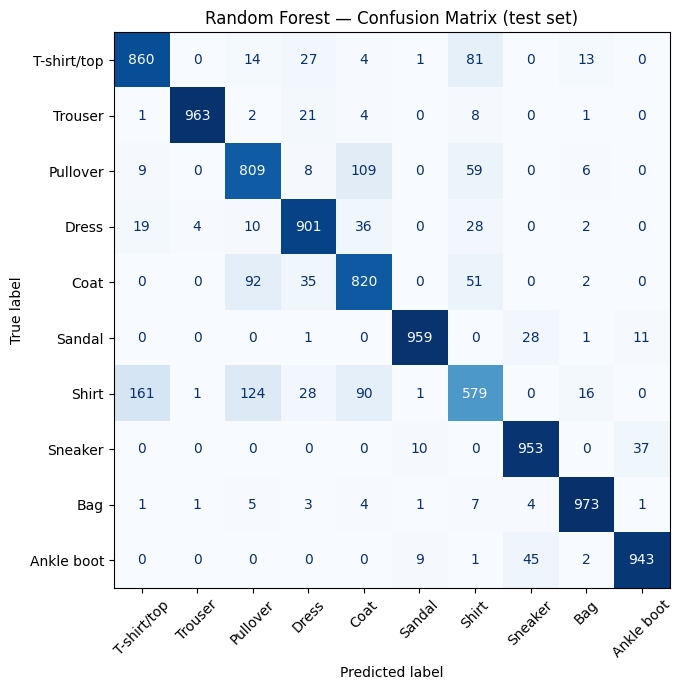

In [ ]:
# Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
plt.title("Random Forest — Confusion Matrix (test set)")
plt.tight_layout()
plt.show()


In [25]:
# --- Comparison ensembles: gives you real numbers to MOTIVATE the choice ---
# Plain bagging (no feature subsampling) isolates the effect of RF's random
# feature selection on both accuracy and training speed.

t0 = time.time()
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=20, n_jobs=-1, random_state=42, oob_score=True,
)
bag.fit(x_train_flat, y_train)
bag_fit_time = time.time() - t0
bag_test_acc = accuracy_score(y_test, bag.predict(x_test_flat))
print(f"\n=== Bagging (all features, 20 trees) ===")
print(f"Fit time: {bag_fit_time:.1f}s, test_acc={bag_test_acc:.4f}, "
      f"oob={bag.oob_score_:.4f}")

c:\Users\niels\anaconda3\envs\Machine_Learning\Lib\site-packages\sklearn\ensemble\_bagging.py:917: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
c:\Users\niels\anaconda3\envs\Machine_Learning\Lib\site-packages\sklearn\ensemble\_bagging.py:923: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]



=== Bagging (all features, 20 trees) ===
Fit time: 90.7s, test_acc=0.8616, oob=0.8503


In [26]:
# Gradient boosting represents the BOOSTING paradigm (bias reduction via
# sequential residual fitting) instead of bagging's variance reduction.

t0 = time.time()
gb = HistGradientBoostingClassifier(random_state=42, max_iter=150)
gb.fit(x_train_flat, y_train)
gb_fit_time = time.time() - t0
gb_test_acc = accuracy_score(y_test, gb.predict(x_test_flat))
print(f"\n=== Gradient Boosting (150 rounds) ===")
print(f"Fit time: {gb_fit_time:.1f}s, test_acc={gb_test_acc:.4f}")


=== Gradient Boosting (150 rounds) ===
Fit time: 150.5s, test_acc=0.8962


In [27]:
# Summary table for the report

print("\n=== Summary: Tree ensemble comparison ===")
print(f"{'Model':<32}{'Test Acc':>10}{'Fit time (s)':>14}")
print(f"{'Decision tree (unlimited depth)':<32}{tree_test_acc:>10.4f}{'—':>14}")
print(f"{'Decision tree (tuned depth)':<32}{final_tree_test_acc:>10.4f}{'—':>14}")
print(f"{'Bagging (all features)':<32}{bag_test_acc:>10.4f}{bag_fit_time:>14.1f}")
print(f"{'Random Forest (sqrt features)':<32}{rf_test_acc:>10.4f}{rf_fit_time:>14.1f}")
print(f"{'Gradient boosting':<32}{gb_test_acc:>10.4f}{gb_fit_time:>14.1f}")


=== Summary: Tree ensemble comparison ===
Model                             Test Acc  Fit time (s)
Decision tree (unlimited depth)     0.7890             —
Decision tree (tuned depth)         0.8009             —
Bagging (all features)              0.8616          90.7
Random Forest (sqrt features)       0.8760          13.0
Gradient boosting                   0.8962         150.5
